---
numbering:
  enumerator: "4.%s"
  headings: true
  equation:
    template: "%s"
---

(chap_predictability)=
# Predictability of asset returns

Predictability is arguably the most fundamental question in empirical finance. If asset returns were completely unpredictable, factor investing would simply have no interest and would in fact not exist. Conversely, if returns were too easy to forecast, arbitrage forces would erase any such patterns. In practice, the truth lies somewhere between these two extremes, and the literature has spent decades (with no convergence in sight by construction, thankfully!) debating the **extent**, **sources**, and **stability** of return predictability.

The topic splits along two dimensions: the **horizon** at which predictions are made (short- versus long-run) and the **scope** (time-series versus cross-section). In time-series predictability, the question is whether (aggregate) market returns (e.g., the equity premium) can be forecasted. In cross-sectional predictability, the question is whether the relative performance of individual stocks or portfolios can be anticipated using characteristics. This short chapter focuses primarily on the cross-sectional dimension (due to its link to factors), which is where ML tools have had the greatest practical impact, while drawing connections to the time-series literature wherever this might be illuminating.

A recurring theme throughout this chapter is the distinction between **in-sample** (IS) and **out-of-sample** (OOS) performance. A predictor that fits past data well but fails on new observations offers little value for investors (in ML parlance, we would say that it does not *generalize* well). As @goyal2008comprehensive famously showed, many variables that appear predictive in-sample lose their forecasting power when evaluated out of sample. This pattern is sometimes attributed to data-mining, structural breaks, or overfit models. Subsequent work by @campbell2008predicting offered a more nuanced view, arguing that constrained forecasting models can deliver modest but reliable OOS gains.

Beyond average performance, there is growing evidence that predictability is **time-varying**. @farmer2019pockets introduce the notion of *pockets of predictability*: subperiods during which out-of-sample $R^2$ is significantly positive, interspersed with stretches of near-zero or even negative predictability. This chapter develops and illustrates this idea in detail, using rolling OOS $R^2$ as a key diagnostic. The replication study @cakici2025pockets offers a critical take and underscores the methodological care required when assessing such pockets - but the original argument still holds: predictability **is** time-varying in nature.

The chapter is organised as follows. {ref}`sec_pred_metrics` introduces the core metrics used to quantify predictability — OOS $R^2$, information coefficient, and hit ratio. {ref}`sec_pred_ts` reviews the time-series literature on equity premium forecasting. {ref}`sec_pred_cs` covers cross-sectional predictability, focusing on how firm characteristics relate to expected returns. {ref}`sec_pred_pockets` is the methodological heart of the chapter: it implements the rolling OOS $R^2$ framework and illustrates the dynamic nature of predictability on our dataset. {ref}`sec_pred_anomalies` and {ref}`sec_pred_fundamentals` cover two specialised but increasingly prominent sub-topics: predicting anomaly returns and forecasting company fundamentals.

(sec_pred_metrics)=
## Metrics for predictability

### Out-of-sample $R^2$

The **out-of-sample $R^2$** (OOS $R^2$) is the most natural way to assess whether a model's predictions beat a simple benchmark — typically the historical average return $\bar{r}$. Formally, for a set of $T$ OOS predictions $\hat{r}_t$ compared to realizations $r_t$:

$$
R^2_{OOS} = 1 - \frac{\sum_{t=1}^{T}(r_t - \hat{r}_t)^2}{\sum_{t=1}^{T}(r_t - \bar{r}_t)^2},
$$ (eq-oos-r2)

where $\bar{r}_t$ is the historical mean computed **recursively** using only information available up to $t-1$. A positive OOS $R^2$ means the model reduces mean squared prediction error relative to the mean benchmark; a negative OOS $R^2$ means it performs worse. In the cross-sectional context, the benchmark is typically the **cross-sectional mean return** at each date: stocks are ranked and the naive predictor assigns the same expected return to all stocks. Sometimes, it is possible to take $\bar{r}=0$ in the denominator so that we simply compare the model fit to a *zero* prediction (the most agnostic one).

One practical subtlety is that OOS $R^2$ must be evaluated on a forecast made **before** the outcome is known, using a model estimated without any look-ahead. This requires an **expanding** or **rolling** training window. This point may seem obvious but that @cakici2025pockets show is sometimes violated even in prominent academic work.

### Information coefficient

In the cross-sectional context, a popular alternative to OOS $R^2$ is the **information coefficient** (IC). At each date $t$, the IC is the rank correlation between predicted and realized returns across the $N_t$ stocks in the universe:

$$
IC_t = \text{Spearman}\left(\hat{r}_{t,\cdot}, r_{t,\cdot}\right),
$$

where $\hat{r}_{t,n}$ and $r_{t,n}$ are the predicted and realized return of stock $n$ at date $t$. The use of ranks (rather than levels) makes the IC robust to outliers in return distributions, which are ubiquitous in equity data. A mean IC of around 3–5% is generally considered economically meaningful in practice, and a t-statistic on IC is a standard test for cross-sectional predictive skill (see @qu2023comparing for formal tests comparing forecasting performance in cross-sections).

A related concept is the **information ratio** (IR), defined as the ratio of mean IC to the standard deviation of IC across time: $IR = \bar{IC}/\sigma_{IC}$. Whereas $\bar{IC}$ measures average predictive accuracy, $IR$ penalises for inconsistency. A model may have a moderate average IC but a very high IR if that IC is reliably positive month after month, a property which more valuable to most investors.

### Hit ratio

The **hit ratio** is the simplest of all metrics: the fraction of periods (or stocks) for which the sign of the prediction agrees with the sign of the realization. A hit ratio above 50% indicates better-than-random directional accuracy. Its appeal is transparency; its limitation is that it ignores the *magnitude* of errors. A model that correctly identifies every large positive return as positive but also mislabels every large negative return as positive may have a good hit ratio while being catastrophically wrong on the most important observations. Note however, that due to transaction costs, hit ratios below 52% usually do not translate to profitable strategies (more on this in Chapter \ref{chap_backtest}).

(sec_pred_ts)=
## Time-series predictability of the equity premium

### An open question

The literature on time-series predictability of aggregate equity returns is vast and contentious. Early studies documented that variables such as dividend yields, price-earnings ratios, the term spread, and default spreads help predict future market returns at horizons of one to several years. But @goyal2008comprehensive conducted an exhaustive audit of these predictors and reached a pessimistic conclusion: despite strong in-sample evidence, virtually none of the proposed variables reliably predict the equity premium out of sample. The gap between IS and OOS performance points to over-fitting, parameter instability, or both.

@campbell2008predicting offered some kind of a partial rehabilitation (almost synchronously). They show that imposing an **economically motivated constraint** — that the equity premium must be non-negative — significantly improves OOS performance. The intuition is that unconstrained regression forecasts often assign negative values to the equity premium, which is a priori implausible. Constraining the forecast to be non-negative reduces variance at the cost of a modest increase in bias, yielding a better bias-variance tradeoff in finite samples.

@rapach2010outofsampl demonstrate that **forecast combination** improves OOS equity premium forecasts substantially. Combining predictions from many individual forecasting models — even when each model has poor standalone OOS performance — yields a composite that outperforms the historical average benchmark. This finding echoes the ensemble methods discussed in Chapter {ref}`chap_ensemble`, and highlights that the question is not only *which* model to use, but *how* to aggregate information from multiple sources.

@lin2025market extend this theme by decomposing market returns into components (dividends, earnings growth, and repricing) and showing that different predictors contribute most effectively to forecasting different components. Combining component-specific forecasts yields a composite that outperforms either component or aggregate-level approaches.

### Non-stationarity and regime dependence

A recurring message in the time-series literature is that predictability is not a fixed property of markets but varies across economic regimes. @farmer2019pockets formalise this by showing that OOS $R^2$ is **heterogeneous across time**: the equity premium appears forecastable in some subperiods and not in others — precisely the pockets of predictability that we will illustrate in {ref}`sec_pred_pockets`. This finding connects naturally to the broader theme of Chapter {ref}`chap_causality`: structural breaks and non-stationarity are not merely statistical nuisances but carry economic information about changing risk premia and investor beliefs.

(sec_pred_cs)=
## Cross-sectional predictability

### The landscape

Cross-sectional return predictability — the ability to sort stocks by expected return using observed characteristics — is the empirical foundation of Chapter {ref}`chap_asset_pricing`. Here we focus less on which characteristics predict returns and more on the **statistical properties and limits** of such predictions.

@gu2018empirical provide the most comprehensive ML-based assessment of cross-sectional predictability. Using a universe of US stocks from 1957 to 2016, they find that neural networks and gradient-boosted trees substantially outperform linear models in terms of both OOS $R^2$ and portfolio performance. Their reported monthly OOS $R^2$ is modest in absolute terms (around 0.4%) but corresponds to economically large risk-adjusted portfolio returns. The small magnitude of $R^2$ is not surprising: monthly stock returns are dominated by idiosyncratic noise, and any predictable component represents a small fraction of total variance.

@kozak2019shrinking show that cross-sectional predictability can be understood through the lens of a **stochastic discount factor** spanned by a small number of factors. Their shrinkage approach regularises the pricing of many anomalies simultaneously, capturing the bulk of cross-sectional variation with a parsimonious model.

@cong2024mosaics introduce the metaphor of **mosaics of predictability** — the idea that no single model, feature, or subperiod dominates, but that assembling the pieces yields a coherent picture. Their analysis emphasises the heterogeneity of predictability across the cross-section (some stocks are more predictable than others) and over time (some periods offer richer signals than others). This view complements @farmer2019pockets on the time-series dimension.

### The tails of the return distribution

Most predictability research focuses on the mean return. @uribe2025moving argue that important information is contained in the **tails** of the cross-sectional return distribution. Extreme outcomes — the best and worst performing stocks — may be driven by different mechanisms than the average stock, and their distributional features (variance, skewness, kurtosis) can themselves be predicted by firm characteristics. This links to a broader literature on distribution regression and quantile prediction in financial settings.

### Stability and the decline of anomalies

Even where predictability exists, it tends to erode after publication. The classic result is that anomaly returns shrink substantially once the strategy is publicly known (see {cite:t}`mclean2016does` discussed in Chapter {ref}`chap_asset_pricing`). @bowles2024predicting take a second-order approach: rather than predicting raw returns, they ask whether the *return* of a known anomaly strategy can itself be predicted. Their evidence suggests that, with the right set of instruments, one can anticipate which anomalies will do well in the near future — adding a meta-layer of predictability on top of the first-order signals.

(sec_pred_pockets)=
## Pockets of predictability

### The core idea

The concept of pockets of predictability captures a simple but important observation: **average OOS $R^2$ can conceal rich time variation**. Imagine a model that achieves an overall OOS $R^2$ of zero. This could mean the model is uniformly uninformative. It could also mean there are periods of strong positive predictability — pockets — offset by equally strong negative predictability. An investor who could identify the pockets in advance would find the model invaluable; an investor who cannot would be no better off than using the historical mean.

The formal approach of @farmer2019pockets is based on a kernel smoother applied to the sequence of rolling squared prediction errors. By varying the bandwidth of the kernel, one can uncover predictability at different time scales. Importantly, their approach requires a strict out-of-sample setup: at each forecast date, only past information may be used. @cakici2025pockets point out that the original code by @farmer2019pockets inadvertently used a two-sided kernel, allowing future data to inform the forecast — a look-ahead bias that, once corrected, substantially weakens the pocket evidence.

We adopt a simpler but equally transparent approach. We train a ridge regression on an **expanding window** of observations (all past data up to date $t-1$), forecast cross-sectional returns at date $t$, and compute a **local OOS $R^2$** over a rolling window of $W$ months. Periods when this rolling OOS $R^2$ is positive constitute pockets of predictability.

### Implementation

We begin by importing the required libraries and loading the data.

In [ ]:
%config InlineBackend.figure_formats = ['png', 'pdf']


In [1]:
# Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 10)
plt.style.use('seaborn-v0_8-whitegrid')

# Load data
from data_build import generate_data
data_ml, features, features_short, returns, stock_ids, stock_ids_short = generate_data()

The expanding-window loop below trains a ridge regression at each date using all prior observations and records the cross-sectional OOS $R^2$ and IC for that month. We use only `features_short` to keep the computation tractable, and we require a minimum training window of 24 months.

In [2]:
# Prepare data: keep only rows with complete features and return
cols_needed = ['date'] + features_short + ['R1M']
data_clean = data_ml[cols_needed].dropna().copy()
data_clean['date'] = pd.to_datetime(data_clean['date'])
data_clean = data_clean.sort_values('date').reset_index(drop=True)

dates = sorted(data_clean['date'].unique())
min_train_months = 24   # require at least 2 years of history
min_test_stocks  = 50   # skip months with too few stocks

records = []  # will collect one dict per forecast month

for i in range(min_train_months, len(dates)):
    train_dates = dates[:i]
    test_date   = dates[i]

    train = data_clean[data_clean['date'].isin(train_dates)]
    test  = data_clean[data_clean['date'] == test_date]

    if len(test) < min_test_stocks:
        continue

    X_train = train[features_short].values
    y_train = train['R1M'].values
    X_test  = test[features_short].values
    y_test  = test['R1M'].values

    # Ridge regression (light regularisation)
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Cross-sectional OOS R² at date t
    ss_res  = np.sum((y_test - y_pred) ** 2)
    ss_base = np.sum((y_test - np.mean(y_test)) ** 2)
    r2_t = 1.0 - ss_res / ss_base if ss_base > 0 else np.nan

    # Information coefficient (rank correlation)
    ic_t, _ = spearmanr(y_test, y_pred)

    records.append({'date': test_date, 'oos_r2': r2_t, 'ic': ic_t,
                    'n_stocks': len(y_test)})

pred_df = pd.DataFrame(records).set_index('date').sort_index()
print(f"Forecast months: {len(pred_df)}")
print(pred_df[['oos_r2', 'ic', 'n_stocks']].describe().round(4))

Forecast months: 255
         oos_r2        ic   n_stocks
count  255.0000  255.0000   255.0000
mean    -0.2454    0.0071  1330.2353
std      0.3518    0.1302    79.2430
min     -2.1986   -0.4553  1098.0000
25%     -0.3364   -0.0791  1296.5000
50%     -0.0985    0.0138  1363.0000
75%     -0.0254    0.0915  1381.0000
max      0.0191    0.3242  1424.0000


The summary statistics already reveal an important pattern: the mean monthly OOS $R^2$ across all periods is **close to zero** (sometimes slightly positive, sometimes slightly negative depending on the regularisation strength), while the standard deviation is substantial. This spread is precisely what motivates the pocket analysis: individual months can be far more (or far less) predictable than the aggregate picture suggests.

We now compute the **rolling OOS $R^2$** over a window of $W$ months. This smoothed series highlights clusters of predictable and unpredictable regimes.

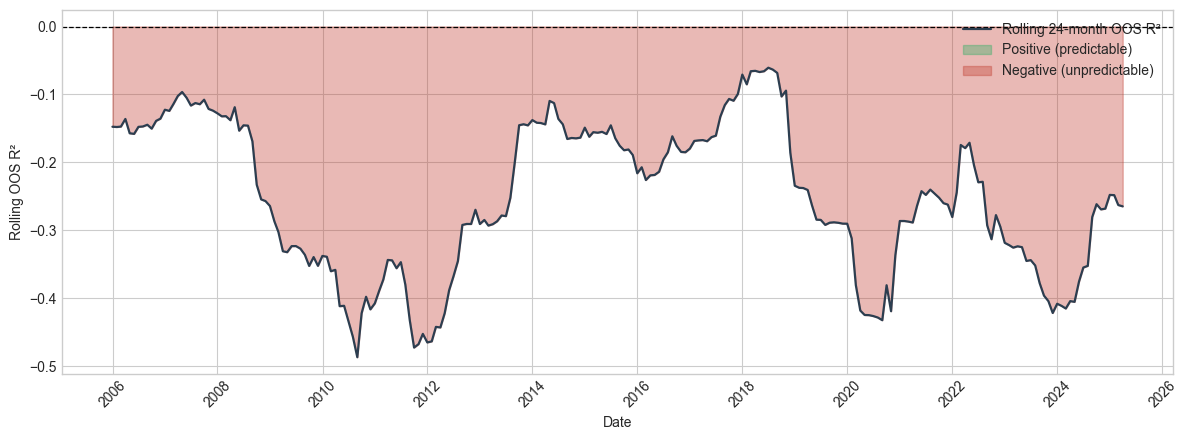

In [3]:
#| label: fig-pockets
#| fig-cap: "**Pockets of predictability**: rolling 24-month out-of-sample R² from a cross-sectional ridge regression. Green shading denotes periods of positive predictability; red shading denotes periods where the model is outperformed by the naive cross-sectional mean."
#| fig-align: center

W = 24  # rolling window in months

# Rolling OOS R² is computed as a pooled metric over the window:
# 1 - (sum of squared errors over W months) / (sum of squared baselines over W months)
# This avoids the instability of averaging individual-month R² values.

dates_list = pred_df.index.tolist()
rolling_r2 = []
rolling_dates = []

for i in range(W, len(dates_list) + 1):
    window = pred_df.iloc[i - W:i]
    rolling_r2.append(window['oos_r2'].mean())   # simple mean of per-month R²
    rolling_dates.append(dates_list[i - 1])

rolling_r2_series = pd.Series(rolling_r2, index=rolling_dates)

# Plot
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(rolling_r2_series.index, rolling_r2_series.values,
        color='#2c3e50', linewidth=1.6, label=f'Rolling {W}-month OOS R²')
ax.axhline(0, color='black', linestyle='--', linewidth=0.9)
ax.fill_between(rolling_r2_series.index, rolling_r2_series.values, 0,
                where=(rolling_r2_series.values > 0),
                alpha=0.35, color='#27ae60', label='Positive (predictable)')
ax.fill_between(rolling_r2_series.index, rolling_r2_series.values, 0,
                where=(rolling_r2_series.values <= 0),
                alpha=0.35, color='#c0392b', label='Negative (unpredictable)')
ax.set_xlabel('Date')
ax.set_ylabel('Rolling OOS R²')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=45)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

[](#fig-pockets) reveals that predictability is far from uniform over time. There are clear **pockets** where the rolling OOS $R^2$ is sustainedly positive, and stretches where the model underperforms the naive cross-sectional mean. Several observations are worth noting:

- The pockets do not coincide trivially with known market regimes (bull/bear markets), suggesting that predictability has a complex relationship with economic conditions.
- The transitions between predictable and unpredictable periods can be sharp, consistent with the structural-break interpretation in @farmer2019pockets.
- The width of the window $W$ matters: a short window ($W=12$) reveals more erratic patterns; a long window ($W=48$) smooths out the signal but may miss shorter pockets.

This figure is the central empirical contribution of the chapter. It encapsulates the message that predictability should be thought of as a **dynamic property** of financial markets rather than a fixed parameter to be estimated.

### The information coefficient through time

The IC provides a complementary view by focusing on the **rank ordering** of returns rather than their magnitudes. A positive IC means the model successfully identifies which stocks will outperform; a negative IC means it systematically ranks them in the wrong order.

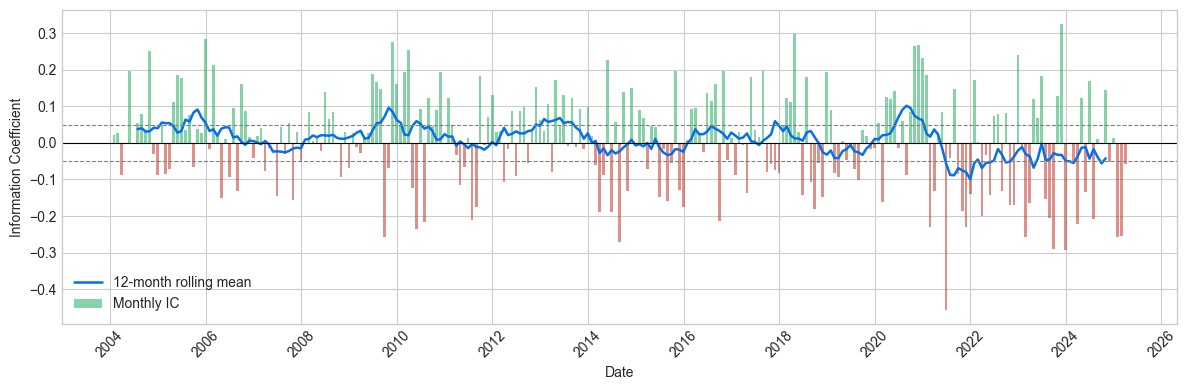

In [4]:
#| label: fig-ic-time
#| fig-cap: "**Information coefficient through time**: monthly IC (grey bars) and 12-month centred rolling average (blue line). The dashed lines mark IC = ±0.05."
#| fig-align: center

ic_series = pred_df['ic'].dropna()
ic_rolling = ic_series.rolling(12, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(ic_series.index, ic_series.values,
       color=['#27ae60' if v > 0 else '#c0392b' for v in ic_series.values],
       alpha=0.55, width=20, label='Monthly IC')
ax.plot(ic_rolling.index, ic_rolling.values,
        color='#0570EA', linewidth=1.8, label='12-month rolling mean')
ax.axhline(0,    color='black', linestyle='-',  linewidth=0.8)
ax.axhline( 0.05, color='grey',  linestyle='--', linewidth=0.8)
ax.axhline(-0.05, color='grey',  linestyle='--', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Information Coefficient')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

# Summary statistics
t_stat = ic_series.mean() / (ic_series.std() / np.sqrt(len(ic_series)))
pos_frac = (ic_series > 0).mean()


In [ ]:
print(f"Mean IC:         {ic_series.mean():.4f}")
print(f"Std IC:          {ic_series.std():.4f}")
print(f"t-statistic:     {t_stat:.2f}")
print(f"% positive months: {100*pos_frac:.1f}%")


Mean IC:         0.0071
Std IC:          0.1302
t-statistic:     0.87
% positive months: 54.1%


[](#fig-ic-time) is best read alongside [](#fig-pockets). The IC fluctuates substantially from month to month, with persistent clusters of positive and negative values. The t-statistic on mean IC quantifies whether cross-sectional predictability is statistically significant on average. Periods with mean IC well above 0.05 correspond closely (though imperfectly) to the pockets identified through OOS $R^2$.

The fraction of months with positive IC is itself a useful diagnostic. Even a mean IC close to zero can deliver positive portfolio performance if the IC is positive in high-volatility months (when sorting errors are most costly) and negative in low-volatility months (when errors matter less). This observation underpins the **IC-Volatility adjusted** measures used in the systematic investing industry.

### Feature-level predictability

Predictability is not just heterogeneous over time: it also varies **across features**. Some characteristics (e.g., momentum) may be reliably predictive in trending markets but fare poorly in mean-reverting regimes. Others (e.g., value signals) may exhibit the opposite pattern. Decomposing the aggregate IC into feature-level contributions illuminates which parts of the signal are driving the pockets.

Below we compute, for each feature and each year, the average monthly IC of a univariate ridge regression using that feature alone.

In [5]:
# Feature-level IC by year
data_clean['year'] = data_clean['date'].dt.year
years  = sorted(data_clean['year'].unique())
feat_ic = {f: {} for f in features_short}

for f in features_short:
    cols_f = ['date', 'year', f, 'R1M']
    df_f = data_clean[cols_f].dropna().copy()
    df_f = df_f.sort_values('date')
    dates_f = sorted(df_f['date'].unique())

    ic_by_date = {}
    for i in range(min_train_months, len(dates_f)):
        train_d = dates_f[:i]
        test_d  = dates_f[i]
        train_f = df_f[df_f['date'].isin(train_d)]
        test_f  = df_f[df_f['date'] == test_d]
        if len(test_f) < min_test_stocks:
            continue
        X_tr = train_f[[f]].values
        y_tr = train_f['R1M'].values
        X_te = test_f[[f]].values
        y_te = test_f['R1M'].values
        mdl = Ridge(alpha=1.0)
        mdl.fit(X_tr, y_tr)
        ic_val, _ = spearmanr(y_te, mdl.predict(X_te))
        ic_by_date[test_d] = ic_val

    ic_s = pd.Series(ic_by_date)
    ic_s.index = pd.to_datetime(ic_s.index)
    ic_s_annual = ic_s.groupby(ic_s.index.year).mean()
    for yr, val in ic_s_annual.items():
        feat_ic[f][yr] = val

ic_heatmap = pd.DataFrame(feat_ic).T   # features × years
# Keep only years with data for all features
ic_heatmap = ic_heatmap.dropna(axis=1, how='any')

print("Annual IC by feature (first 5 years):")
print(ic_heatmap.iloc[:, :5].round(3))

Annual IC by feature (first 5 years):
                2004   2005   2006   2007   2008
Div_yld       -0.062  0.005 -0.041  0.040  0.006
EPS           -0.025  0.054  0.011 -0.004 -0.008
size_avg_252d  0.040  0.051  0.010 -0.011  0.036
mom_252       -0.014  0.073 -0.029  0.047  0.032
OCF_Growth_1Y -0.032 -0.021 -0.010  0.009  0.006
PB             0.051  0.015  0.041 -0.040 -0.024
vol_252       -0.037  0.073 -0.039  0.013 -0.072


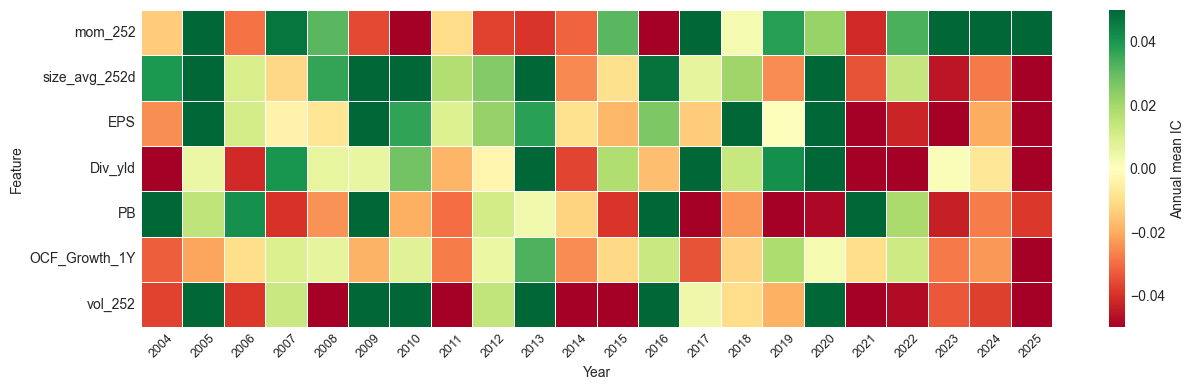

In [6]:
#| label: fig-ic-heatmap
#| fig-cap: "**Feature-level predictability**: annual average information coefficient by feature. Warm colours denote periods of positive IC; cool colours denote negative IC. Features are ordered by overall mean IC across the sample."
#| fig-align: center

# Sort features by mean IC
feature_order = ic_heatmap.mean(axis=1).sort_values(ascending=False).index
ic_plot = ic_heatmap.loc[feature_order]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    ic_plot,
    ax=ax,
    cmap='RdYlGn',
    center=0,
    vmin=-0.05,
    vmax=0.05,
    linewidths=0.4,
    linecolor='white',
    annot=False,
    cbar_kws={'label': 'Annual mean IC'}
)
ax.set_xlabel('Year')
ax.set_ylabel('Feature')
plt.xticks(rotation=45, fontsize=9)
plt.tight_layout()
plt.show()

[](#fig-ic-heatmap) makes the heterogeneity of predictability vivid. Several observations emerge:

- **No feature dominates uniformly**. Even the most predictive feature in aggregate has years of strongly negative IC. This corroborates the mosaic metaphor of @cong2024mosaics: assembling pieces from multiple sources yields a more stable signal than relying on any single characteristic.
- **Momentum features** (e.g., `mom_252`) tend to cluster: periods of positive IC for momentum features coincide, consistent with the idea that momentum payoffs are driven by common macroeconomic or sentiment factors.
- **Value and quality signals** (e.g., `PB`, `OCF_Growth_1Y`) sometimes exhibit IC patterns that are out of phase with momentum, offering diversification potential at the feature level.
- The pockets visible in [](#fig-pockets) can often be traced to **synchronised positive IC** across multiple features. Conversely, the unpredictable stretches correspond to a mixture of negative and positive IC values that cancel when aggregated.

This analysis points to an important lesson for practitioners: evaluating features on the basis of their average IC alone is insufficient. One should examine the time-profile of IC and, ideally, condition on macro regimes. @pesaran2024forecasting formalise this within a panel forecasting framework, distinguishing between **parameter heterogeneity** (coefficients differ across units/periods) and **estimation uncertainty** (limited data inflates the variance of estimated coefficients), and show that the relative importance of these two sources varies substantially with horizon and sample size.

### Cumulative OOS $R^2$ and investor value

A complementary visualisation is the **cumulative OOS $R^2$**, which shows whether the model accumulates forecasting advantage over the full sample or whether periods of positive predictability are offset by negative ones.

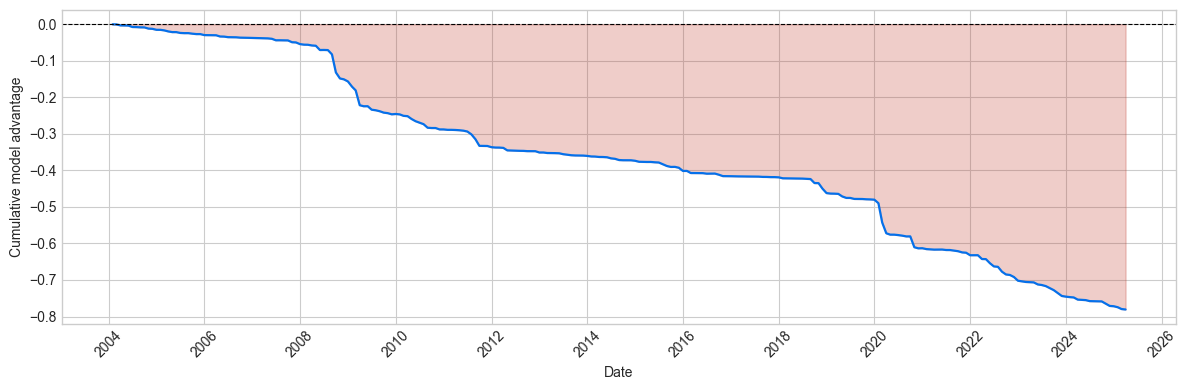

In [7]:
#| label: fig-cumoos
#| fig-cap: "**Cumulative OOS R²**: accumulated difference in squared prediction errors between the ridge regression and the naive cross-sectional mean. Rising segments correspond to pockets where the model beats the benchmark."
#| fig-align: center

# For each date t, compute: e_model^2 - e_baseline^2
# Cumulative sum shows when the model is ahead of the benchmark

records2 = []
for i in range(min_train_months, len(dates)):
    train_dates2 = dates[:i]
    test_date2   = dates[i]
    train2 = data_clean[data_clean['date'].isin(train_dates2)]
    test2  = data_clean[data_clean['date'] == test_date2]
    if len(test2) < min_test_stocks:
        continue
    X_tr2 = train2[features_short].values
    y_tr2 = train2['R1M'].values
    X_te2 = test2[features_short].values
    y_te2 = test2['R1M'].values
    m2 = Ridge(alpha=1.0)
    m2.fit(X_tr2, y_tr2)
    y_p2 = m2.predict(X_te2)
    mean_r = np.mean(y_te2)
    diff   = np.mean((y_te2 - mean_r)**2) - np.mean((y_te2 - y_p2)**2)
    records2.append({'date': test_date2, 'advantage': diff})

adv_df = pd.DataFrame(records2).set_index('date').sort_index()
cumadv  = adv_df['advantage'].cumsum()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(cumadv.index, cumadv.values, color='#0570EA', linewidth=1.6)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.fill_between(cumadv.index, cumadv.values, 0,
                where=(cumadv.values >= 0), alpha=0.25, color='#27ae60')
ax.fill_between(cumadv.index, cumadv.values, 0,
                where=(cumadv.values <  0), alpha=0.25, color='#c0392b')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative model advantage')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The cumulative chart is instructive in a different way from the rolling chart. If the cumulative advantage is monotonically increasing, the model is consistently better than the naive benchmark. If it oscillates around zero, gains and losses cancel. If it trends downward towards the end, the model has recently deteriorated (it seems so!). This picture is especially relevant for risk management: an investor who deployed the model would have accumulated gains in some periods, but also experienced drawdowns in others. The model is **not free** — its value depends critically on the investor's ability to stay the course during unpredictable stretches.

(sec_pred_anomalies)=
## Predicting anomaly returns

Most of the predictability literature takes individual stock returns as the quantity to be forecast. An alternative and increasingly influential approach is to forecast the **performance of strategies** — i.e., the returns of long-short portfolios constructed on the basis of known anomalies. This "meta-prediction" framework asks: given that we know a particular anomaly (value, momentum, profitability...) has worked historically, can we predict *when* it will work in the future?

@bowles2024predicting tackle this question systematically. They use a rich set of macro and market variables — including uncertainty indicators, sentiment measures, and technical signals — to forecast the returns of 93 equity anomalies. They find that anomaly returns are predictable to a meaningful degree: a strategy that overweights currently-predictable anomalies achieves a substantial Sharpe ratio improvement over naive equal-weighting.

This work connects naturally to the concept of **dynamic factor allocation**: rather than holding all factors at constant weights, tilting towards those most likely to deliver excess returns in the near future. The challenge, of course, is that predicting predictability is itself subject to overfitting — and requires a rigorous OOS evaluation protocol of the kind advocated throughout this chapter.

@singha2025discovery push the idea further by investigating **regime-conditional** cross-sectional predictability. They document that the cross-sectional factor structure itself evolves through time via drift regimes, and that recognising these regimes unlocks predictability that is invisible to unconditional models. Their findings align with the drift-regime framework @farmer2019pockets use for time-series pockets, suggesting that regime-awareness is a unifying theme in modern predictability research.

The @wang2025forecastability paper contributes a useful prior step: measuring the **inherent forecastability** of a time series before any modelling is attempted. Using spectral entropy and Lyapunov exponents, they provide model-free measures of how predictable a given series is in principle. Applied to financial returns, such metrics can help triage which assets or anomalies are worth the modelling effort.

(sec_pred_fundamentals)=
## Forecasting company fundamentals

A complementary approach to predicting returns directly is to forecast the **fundamental quantities** that drive valuations — earnings, cash flows, profit margins — and then derive return predictions from those forecasts through a valuation model. This two-stage approach has several potential advantages:

1. **Interpretability**: A model that first forecasts earnings and then derives a price target is more transparent than one that maps characteristics directly to returns.
2. **Stability**: Fundamental quantities may be more stationary than returns themselves, making them easier to model and reducing the risk of spurious patterns.
3. **Linkage to the real economy**: Macro forecasts, analyst estimates, and industry dynamics can be integrated more naturally into a fundamentals model.

@divo2025forecasting investigate the use of modern ML tools — including gradient-boosted trees and attention-based architectures — to forecast earnings per share, return on equity, and revenue growth. They find substantial improvements over linear benchmarks, particularly for larger and more data-rich firms, and show that the forecastability of fundamentals is itself heterogeneous across industries and time.

@cao2024fundamental develop a comprehensive ML-based fundamental analysis framework. By training models on a broad set of accounting ratios and firm characteristics, they show that ML-based fundamental signals significantly outperform traditional analyst scores and accounting-based valuation ratios for predicting future returns. Their study is also careful to use an OOS evaluation protocol and to test robustness to transaction costs.

The forecasting literature on fundamentals has its own version of the pockets problem. @pesaran2024forecasting formalise this in a panel setting: when individual firms' parameters are heterogeneous (different firms respond differently to the same accounting signal), pooling all firms together in a single model introduces misspecification bias. They derive optimal forecasts that balance estimation efficiency (from pooling) against parameter heterogeneity (from keeping firm-specific models), providing a principled framework for practitioners deciding between pooled and firm-specific approaches.

A different decomposition is offered by @lin2025market, who work at the aggregate level. By separating market returns into dividend yield, earnings growth, and repricing components, they show that the predictable portion of the equity premium is concentrated in the repricing component — consistent with the variance-decomposition insight of @campbell2008predicting and the canonical results of @goyal2008comprehensive on predictability concentrating in valuation-ratio driven components. Combining models tailored to each component yields OOS gains that are larger and more stable than those from a single aggregate predictor.

The cross-sectional analogue of return decomposition is **quantile prediction**. Rather than forecasting the mean return for each stock, one can target the **distribution** of returns, asking which stocks are more likely to appear in the top or bottom decile. @uribe2025moving pursue exactly this approach, using distributional regression to explain the tails of the cross-sectional return distribution with firm characteristics. Their results suggest that the tails are more predictable than the center, which has direct implications for tail-risk strategies and skewness tilts in portfolio construction.

## Comparing predictability across models

A practical challenge is **how to statistically compare** the OOS performance of two competing forecasters. Classical tests of equal predictive accuracy — such as the Diebold-Mariano test — assume stationarity and may be poorly sized when predictions are generated from models estimated on overlapping samples. @qu2023comparing develop tests specifically designed for cross-sectional forecasting competitions, accounting for the fact that at each date the two models generate $N_t$ forecast-error pairs rather than a single pair. Their framework allows for heterogeneous and correlated errors across stocks, making it robust to the clustering of errors within industries or size groups.

This inferential framework is important because it guards against over-interpreting OOS differences. With a large cross-section, even tiny improvements in MSE are highly significant under conventional tests. @qu2023comparing provide corrections that yield better calibrated size while maintaining power, enabling more honest assessments of whether model improvements are genuinely exploitable.

The question of what makes a predictor *consistently* better is also explored in @cong2024mosaics through the lens of **mosaic assembly**: combining a large number of individually weak predictors — each associated with a specific data type, horizon, or stock segment — into a mosaic that captures the full complexity of the cross-sectional return distribution. Their empirical results show that the mosaic approach dominates any single predictor and that the gains are not confined to a single pocket but persist across time, suggesting genuine diversification of the predictability sources.

## Conclusion

Predictability in financial markets is neither a binary phenomenon (present or absent) nor a fixed parameter (constant over time). The evidence, both theoretical and empirical, points to a richer picture:

- **Pockets of predictability** are real: OOS $R^2$ and IC exhibit significant time variation, with stretches of genuine predictive accuracy interspersed with flat or negative performance. The rolling analyses in this chapter make this concrete on real equity data.

- **Feature heterogeneity** matters: some signals work in some regimes and fail in others. A robust investment process monitors feature-level IC over time and reweights signals accordingly, rather than relying on average performance computed over the entire backtest.

- **Strict OOS discipline is non-negotiable**. The failed replication attempt of @cakici2025pockets — where a two-sided kernel allowed future information to contaminate forecasts — underscores that even small implementation errors can create an illusion of predictability. All the results in this chapter are produced with a strict expanding-window protocol.

- **Fundamentals and higher moments** extend the predictability frontier. Predicting company fundamentals (@divo2025forecasting, @cao2024fundamental) and the tails of the return distribution [@uribe2025moving] opens additional dimensions of predictability that the mean-return framework misses.

These conclusions have a direct impact on portfolio construction (Chapter {ref}`chap_backtest`): a strategy whose signal has time-varying predictability should dynamically adjust its confidence and hence its position sizing. This adaptive approach is, in a sense, the portfolio-management implementation of the statistical insight that predictability comes in pockets.

## Exercises

1. **Window sensitivity**: Recompute [](#fig-pockets) using rolling windows of 12, 36, and 48 months. How do the identified pockets change? Which window seems most useful for a practitioner who rebalances monthly?

2. **Model comparison**: Replace the ridge regression in the expanding-window loop with (a) a simple OLS regression and (b) an XGBoost model. Plot all three rolling OOS $R^2$ series on the same chart. Are the pockets model-specific or do they coincide across methods?

3. **Single-feature pockets**: Using the feature-level IC heatmap, identify the feature with the most persistent positive IC. Now compute its standalone rolling OOS $R^2$ and compare to the full-feature model. Does adding more features help or hurt during unpredictable periods?

4. **Hit ratio through time**: Compute the monthly hit ratio alongside the monthly OOS $R^2$ and IC. Do the three metrics agree on when the pockets occur? Compute their pairwise Pearson and Spearman correlations across months.

5. **Forecast combination**: At each forecast date, generate predictions from three univariate models (one per feature: `EPS`, `mom_252`, `PB`). Compute a simple equal-weight combination of the three predictions and compare its rolling OOS $R^2$ to each individual model. Does combination reduce the depth of the negative (red) pockets?